In [2]:
import numpy as np
import pandas as pd
df = pd.read_csv("spam.csv",encoding="latin1")


In [3]:
df.head(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [7]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [8]:
df["Label"]=df["v1"]

In [9]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,Label
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,ham
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,ham
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,spam
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,ham
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,ham
...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN,spam
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN,ham
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN,ham
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN,ham


In [10]:
encoder.fit_transform(df["Label"])

array([0, 0, 1, ..., 0, 0, 0])

In [11]:
df["Label"]=encoder.fit_transform(df["Label"])

In [12]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,Label
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,0
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,1
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,0


In [13]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3','Unnamed: 4'], axis=1)
df.head()

,v1,v2,Label
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [14]:
df.isnull().sum()

v1       0
v2       0
Label    0
dtype: int64

In [15]:
df.duplicated().sum()

403

In [16]:
df = df.drop_duplicates()


In [17]:
df.duplicated().sum()

0

In [18]:
df.shape

(5169, 3)

In [19]:
df["Label"].value_counts()

Label
0    4516
1     653
Name: count, dtype: int64

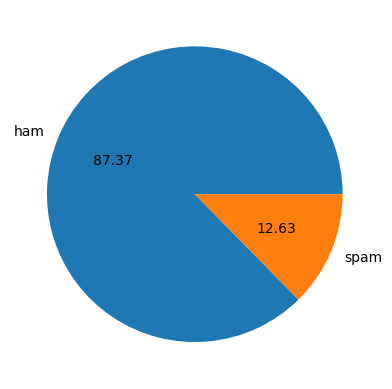

In [20]:
import matplotlib.pyplot as plt
plt.pie(df["Label"].value_counts(),labels=["ham","spam"],autopct="%0.2f")
plt.show()

In [21]:
# Function to count alphabets in a string
def count_alphabets(Email_Content):
    return sum(char.isalpha() for char in Email_Content)
df["Alfabets_count"]=df['v2'].apply(count_alphabets)


In [22]:
df

,v1,v2,Label,Alfabets_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,83
1,ham,Ok lar... Joking wif u oni...,0,18
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,97
3,ham,U dun say so early hor... U c already then say...,0,33
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,47
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1,102
5568,ham,Will Ì_ b going to esplanade fr home?,0,28
5569,ham,"Pity, * was in mood for that. So...any other s...",0,41
5570,ham,The guy did some bitching but I acted like i'd...,0,99


In [23]:
df = df.rename(columns={
    'v2': 'Mails',
})

In [24]:
df.sample(5)

,v1,Mails,Label,Alfabets_count
2729,spam,Urgent! Please call 09066612661 from your land...,1,110
2170,ham,\CAN I PLEASE COME UP NOW IMIN TOWN.DONTMATTER...,0,50
1050,ham,Are you available for soiree on June 3rd?,0,32
2986,ham,"I'm there and I can see you, but you can't see...",0,69
3587,ham,If you were/are free i can give. Otherwise nal...,0,58


In [25]:
df['Word_Count'] = df['Mails'].str.split().str.len()


In [26]:
df

,v1,Mails,Label,Alfabets_count,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",0,83,20
1,ham,Ok lar... Joking wif u oni...,0,18,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,97,28
3,ham,U dun say so early hor... U c already then say...,0,33,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,47,13
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1,102,30
5568,ham,Will Ì_ b going to esplanade fr home?,0,28,8
5569,ham,"Pity, * was in mood for that. So...any other s...",0,41,10
5570,ham,The guy did some bitching but I acted like i'd...,0,99,26


In [27]:
# spams
df[df["Label"]==1][["Alfabets_count","Word_Count"]].describe()

,Alfabets_count,Word_Count
count,653.000000,653.000000
mean,93.650842,23.681470
std,22.196086,5.967672
min,3.000000,2.000000
25%,85.000000,22.000000
50%,99.000000,25.000000
75%,108.000000,28.000000
max,151.000000,35.000000


In [28]:
# hams
df[df["Label"]==0][["Alfabets_count","Word_Count"]].describe()

,Alfabets_count,Word_Count
count,4516.000000,4516.000000
mean,53.017493,14.134632
std,42.437691,11.116240
min,0.000000,1.000000
25%,25.000000,7.000000
50%,40.000000,11.000000
75%,68.000000,18.000000
max,718.000000,171.000000


In [29]:
import seaborn as sns

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Alfabets_count', ylabel='Count'>

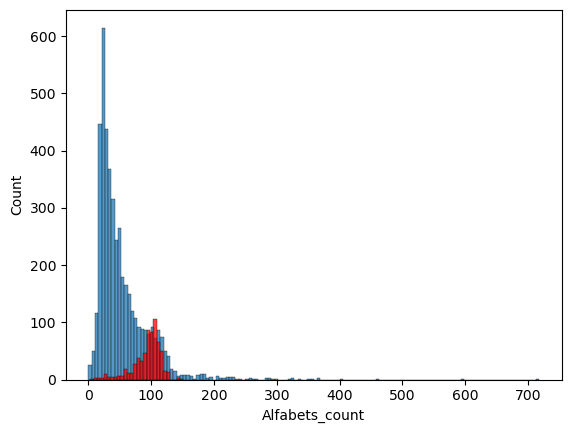

In [30]:
sns.histplot(df[df["Label"]==0]["Alfabets_count"])    #ham
sns.histplot(df[df["Label"]==1]["Alfabets_count"],color='red')    # spam


C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Word_Count', ylabel='Count'>

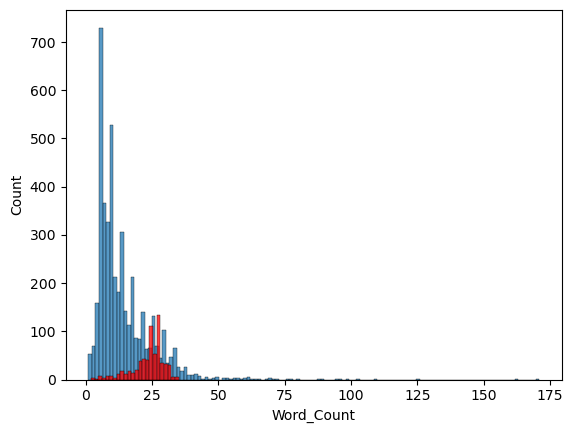

In [31]:
sns.histplot(df[df["Label"]==0]["Word_Count"])    #ham
sns.histplot(df[df["Label"]==1]["Word_Count"],color='red')    # spam

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


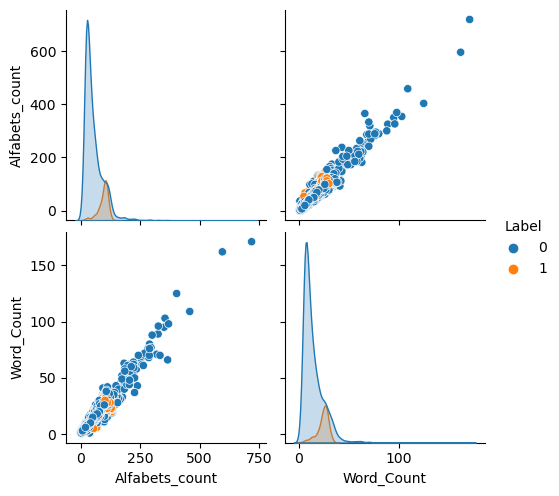

In [32]:
sns.pairplot(df,hue='Label')

# data preprocessing


<!-- Lower case
Tokenization
Removing special characters
Removing stop words and punctuation
Stemming -->

#Lower case
#Tokenization
#Removing special characters
#Removing stop words and punctuation
#Stemming

In [33]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [34]:
df.shape

(5169, 5)

In [35]:
def transform_text(text):
    text = text.lower()                      
    text = nltk.word_tokenize(text)           
  
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)   
    
    text = y[:]          
    y.clear()             
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:       
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
            
    return " ".join(y)

In [36]:
transform_text("we presenting our project in class ?")

'present project class'

In [37]:
df['Mails']=df['Mails'].apply(transform_text)

In [38]:
df.shape

(5169, 5)

In [39]:
print(df['Mails'].isnull().sum()) 

0


In [40]:
df['Mails']=df["Mails"].tolist()

In [41]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

# Model building 

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X = tfidf.fit_transform(df['Mails'])
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

 # MultinomialNB naive bayes

In [44]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [45]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [46]:
y_pred = nb.predict(X_test)

In [47]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9716

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1331
           1       0.99      0.81      0.89       220

    accuracy                           0.97      1551
   macro avg       0.98      0.90      0.94      1551
weighted avg       0.97      0.97      0.97      1551


Confusion Matrix:
 [[1329    2]
 [  42  178]]


# Testing.

In [53]:
new_email = ["WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only"]
new_email_transformed = tfidf.transform(new_email)  # Convert text into numerical features
prediction = nb.predict(new_email_transformed)

if prediction[0] == 1:
    print("🚨 Spam Email 🚨")
else:
    print("✅ Ham (Not Spam) Email ✅")


🚨 Spam Email 🚨


# Confusion  matrix

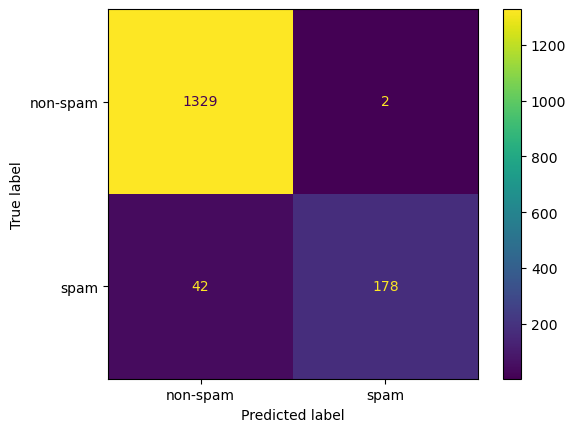

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(nb, X_test, y_test, display_labels=["non-spam", "spam"])
plt.show()